In [1]:
import pandas as pd
import numpy as np
import pickle
import keras
from sklearn.metrics import r2_score, mean_squared_error, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt # 그래프 그리는 라이브러리

In [2]:
PAST_STEP = 36 # 관측 데이터 사용량 (10분단위, 6시간, 36 STEP)
FORECAST_STEP = 72 # 예보 데이터 사용량 ( 10분단위, 12시간, 72 STEP )

# 유량 예측 모델일 시 이 변수 사용
DG_OUTPUT_COL = ['서울시(대곡교)_Q']
GN_OUTPUT_COL = ['성남시(궁내교)_Q']
DG_WL_COL = '서울시(대곡교)_WL'
GN_WL_COL = '성남시(궁내교)_WL'
INPUT1_COL = [
                '성남시(한국학중앙연구원)','성남시(대장동)', '성남시(구미초교)',
                '서울시(대곡교)',  '성남시(성남북초교)', '광주시(남한산초교)',
                '궁내교_Ti', '대곡교_Ti', '성남시(궁내교)_Q', '서울시(대곡교)_Q' ]

# 수위 예측 모델일 시 이 변수 사용
# DG_OUTPUT_COL = ['서울시(대곡교)_WL']
# GN_OUTPUT_COL = ['성남시(궁내교)_WL']
# INPUT1_COL = [
#                 '성남시(한국학중앙연구원)','성남시(대장동)', '성남시(구미초교)',
#                 '서울시(대곡교)',  '성남시(성남북초교)', '광주시(남한산초교)',
#                 '궁내교_Ti', '대곡교_Ti', '성남시(궁내교)_WL', '서울시(대곡교)_WL' ]

INPUT2_COL = [
                '성남시(한국학중앙연구원)','성남시(대장동)', '성남시(구미초교)',
                '서울시(대곡교)',  '성남시(성남북초교)', '광주시(남한산초교)',
                '궁내교_Ti', '대곡교_Ti', 
            ]

testdata_dir = './testdata'

testdata_200802 = f'{testdata_dir}/36step/20200802.csv'
testdata_220712 = f'{testdata_dir}/36step/20220712_048.csv'
testdata_230711 = f'{testdata_dir}/36step/20230711_044.csv'
testdata_240723 = f'{testdata_dir}/36step/20240723.csv'
testdata_250716 = f'{testdata_dir}/36step/250716_1700.xlsx'
testdata_250814 = f'{testdata_dir}/36step/250814_0500.xlsx'

# testdata_200802 = f'{testdata_dir}/72step/20200802.csv'
# testdata_220712 = f'{testdata_dir}/72step/20220712_048.csv'
# testdata_230711 = f'{testdata_dir}/72step/20230711_044.csv'
# testdata_240723 = f'{testdata_dir}/72step/20240723.csv'
# testdata_250716 = f'{testdata_dir}/72step/250716_1700.xlsx'
# testdata_250814 = f'{testdata_dir}/72step/250814_0500.xlsx'

testdata_200802 = pd.read_csv(testdata_200802) 
testdata_220712 = pd.read_csv(testdata_220712) 
testdata_230711 = pd.read_csv(testdata_230711) 
testdata_240723 = pd.read_csv(testdata_240723) 
testdata_250716 = pd.read_excel(testdata_250716) # 250716 테스트 데이터 Dataframe
testdata_250814 = pd.read_excel(testdata_250814) # 250814 테스트 데이터 Dataframe

# dataset_list = [testdata_220712, testdata_230711, testdata_250716, testdata_250814]

#worker = "swkim"
worker = "jmlee"

# # 모델 저장 경로 
# dir_model = f'./model_stage/{worker}/model_sungnam_{target_key}'

# # 스케일러 저장 경로
# scalerfile = f'./model_stage/{worker}/scaler_{target_key}.pkl'

# # 모델 저장 경로 
# dir_model = f'./model_stage/model_{target_key}36_wl'

# # 스케일러 저장 경로
# scalerfile = f'./model_stage/scaler_{target_key}36_wl.pkl'

# ------------------------------------------------------------------ target_key
target_key = 'gn' # 궁내교
# target_key = 'dg' # 대곡교

TARGET_COL = DG_OUTPUT_COL if target_key == 'dg' else GN_OUTPUT_COL
WL_COL = DG_WL_COL if target_key == 'dg' else GN_WL_COL
#수위
Y_Min = 1.5 if target_key == 'dg' else 0.7
Y_Max = 5.5 if target_key == 'dg' else 3
#유량
# Y_Min = 3.93 if target_key == 'dg' else 1.45
# Y_Max = 712.55 if target_key == 'dg' else 200.45
# ------------------------------------------------------------------ 저장 경로
# 모델 저장 경로 
dir_model = f'./model_stage/model_{target_key}_flow'

# 스케일러 저장 경로
scalerfile = f'./model_stage/scaler_{target_key}_flow.pkl'

#스케일러 로드
with open(scalerfile, 'rb') as file:
    scaler_x = pickle.load(file)
    scaler_f = pickle.load(file)
    scaler_y = pickle.load(file)


In [3]:
model = keras.models.load_model(dir_model) # 모델 로드

In [4]:
import os

def make_input_data(df): 
    # 입력데이터 생성
    df_input1 = df.iloc[:PAST_STEP]
    df_input1 = df_input1[INPUT1_COL]
    input1 = np.array(df_input1)
    
    df_input2 = df.iloc[PAST_STEP:]
    df_output = df_input2[TARGET_COL]
    df_input2 = df_input2[INPUT2_COL]
    
    input2 = np.array(df_input2)
    output = np.array(df_output).flatten()
    
    
    input1 =  scaler_x.transform(input1) # 입력자료 1(관측) 데이터 스케일링
    input2 =  scaler_f.transform(input2) # 입력자료 2(예보) 데이터 스케일링

    input1 = input1.reshape(1, input1.shape[-2], input1.shape[-1])
    input2 = input2.reshape(1, input2.shape[-2], input2.shape[-1])
    
    return input1, input2, output
    
def HQCurve(waterlevel):
    # 수위로 유량을 구하는 곡선식 (23.11 ~ 부터 적용 )
    if waterlevel >= 0.54 and waterlevel <= 1.31 :
        return 40.769 * (waterlevel - 0.540) ** 1.728
    elif waterlevel > 1.31 and waterlevel <= 2.42 :
        return 13.779 * ( waterlevel - 0.040 ) ** 2.649
    else :
        return 22.778 * ( waterlevel - 0.400 ) ** 2.552
        
def QHCurve(flow):
    # 유량으로 수위를 구하는 곡선식 (23.11 ~ 부터 적용 )
    if flow >= HQCurve(0.54) and flow <= HQCurve(1.31) :
        return  0.540 + ( flow / 40.769 ) ** (1/1.728)
    elif flow > HQCurve(1.31) and flow <= HQCurve(2.42) :
        return 0.040 + ( flow / 13.779 ) ** (1/2.649)
    else :
        return 0.400 + ( flow / 22.778 ) ** (1/2.552)

def drawCorrectionGraph(y_real, y_pred, pred_type):
    # 예측 결과 비교 그래프
    # y_real : 관측, y_pred : 예측

    plt.figure(figsize=(15, 8))

    plt.plot(y_real, 'blue')
    plt.plot(y_pred, 'orange')
    # plt.axis
    plt.ylim(Y_Min, Y_Max)
    plt.legend([f'obs', f'pred'], loc='upper left')
    plt.title(f'Tancheon {pred_type} Prediction Result ')
    plt.xlabel('step')
    plt.ylabel(f'{pred_type}(m)')
    
    plt.tight_layout()
    plt.show()



def drawRealGraph(df, TARGET_COL, pred_type='waterlevel'):
    # 관측수위 그래프
    
    y_past = df.iloc[:PAST_STEP][TARGET_COL].to_numpy().astype(float).flatten()

    plt.figure(figsize=(15, 8))
    plt.plot(y_past, 'blue')
    plt.ylim(Y_Min, Y_Max)
    plt.legend(['obs'], loc='upper left')
    plt.title(f'Tancheon {pred_type} Observation Result')
    plt.xlabel('step')
    plt.ylabel(f'{pred_type}(m)')
    
    plt.tight_layout()
    plt.show()


def drawRainGraph(df, target_key):
    # 강우 그래프

    if target_key == 'gn':
        col = '궁내교_Ti'
        title = '궁내교 Ti'
        y_max = 22
    elif target_key == 'dg':
        col = '대곡교_Ti'
        title = '대곡교 Ti'
        y_max = 19
    else:
        raise ValueError("target_key must be 'gn' or 'dg'")

    x    = range(len(df))
    rain = df[col].values

    plt.figure(figsize=(15, 4))
    plt.bar(x, -rain, width=0.5, label=col)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.xlabel('step')
    plt.ylabel('Ti (mm)')
    plt.ylim(-y_max, 0)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def makeResultChart(data, y_pred, r2, mse, mae, rmse):
    # 결과 엑셀 저장

    # ------------------------------------------------------------------ 저장 경로
    out_path = f"./testdata/result/{date}_유량수위곡선식.xlsx"
    
    ROW_START = 36   # 엑셀 38행 (0-based)
    ROW_END   = 72   # 엑셀 73행 (end exclusive)
    # ROW_START = 54   # 엑셀 38행 (0-based)
    # ROW_END   = 72   # 엑셀 73행 (end exclusive)
    N_WRITE   = ROW_END - ROW_START  # 36개
    METRIC_ROW = 0   # 엑셀 2행

    pred_col= {"gn": "궁내교 예측수위", "dg": "대곡교 예측수위"}
    metric_col = {
            "gn": ["궁내교 R2", "궁내교 MSE", "궁내교 MAE", "궁내교 RMSE"],
            "dg": ["대곡교 R2", "대곡교 MSE", "대곡교 MAE", "대곡교 RMSE"],
        }

    if os.path.exists(out_path):
        print(" 기존 파일 로드 : ", out_path)
        dfs = pd.read_excel(out_path)
    else:
        print(" 신규 파일 생성 : ", out_path)
        dfs = data.copy()

    pred_col = pred_col[target_key]

    # 컬럼 없으면 생성
    for col in ["궁내교 예측수위", "대곡교 예측수위"]:
        if col not in dfs.columns:
            dfs[col] = np.nan

    for cols in metric_col.values():
        for c in cols:
            if c not in dfs.columns:
                dfs[c] = np.nan

    # 예측수위 값 추가
    y_pred_36 = np.asarray(y_pred).reshape(-1)
    y_pred_36 = y_pred_36[:N_WRITE]
    
    col_idx = dfs.columns.get_indexer([pred_col])[0]  # 항상 정수 1개
    dfs.iloc[ROW_START:ROW_END, col_idx] = y_pred_36

    # 평가 메트릭 값 추가
    metric_cols = metric_col[target_key]
    dfs.loc[METRIC_ROW, metric_cols] = [r2, mse, mae, rmse]

    # 저장
    dfs.to_excel(out_path, index=False)
    
    print("✅ 저장 완료:", out_path)

In [5]:
# ------------------------------------------------------------------ testdata 선택
#  testdata_200802 , testdata_220712 , testdata_230711 , testdata_240723 , testdata_250716 , testdata_250814
data = testdata_240723 
# ------------------------------------------------------------------ 엑셀 파일 제목에 들어갈 년도 선택
#  200802 , 220712 , 230711 , 240723 , 250716 , 250814
date = 240723  

In [6]:
input1, input2, output = make_input_data(data) # 입 / 출력 데이터 

In [7]:
input1.shape # 입력데이터1 (관측) : 1, 36, 10의 3차원 배열

(1, 36, 10)

In [8]:
y_pred = model.predict([input1, input2]) # 모델 예측 수행
y_pred = scaler_y.inverse_transform(y_pred.reshape(1,-1)) # 예측 결과 역스케일링 (원본 스케일로 변화) => 1, 72, 1 의 3차원 배열
y_pred = y_pred[0] # 1, 72, 1 -> 72, 의 1차원 배열이 되도록 꺼냄

1/1 [==============================] - 2s 2s/step


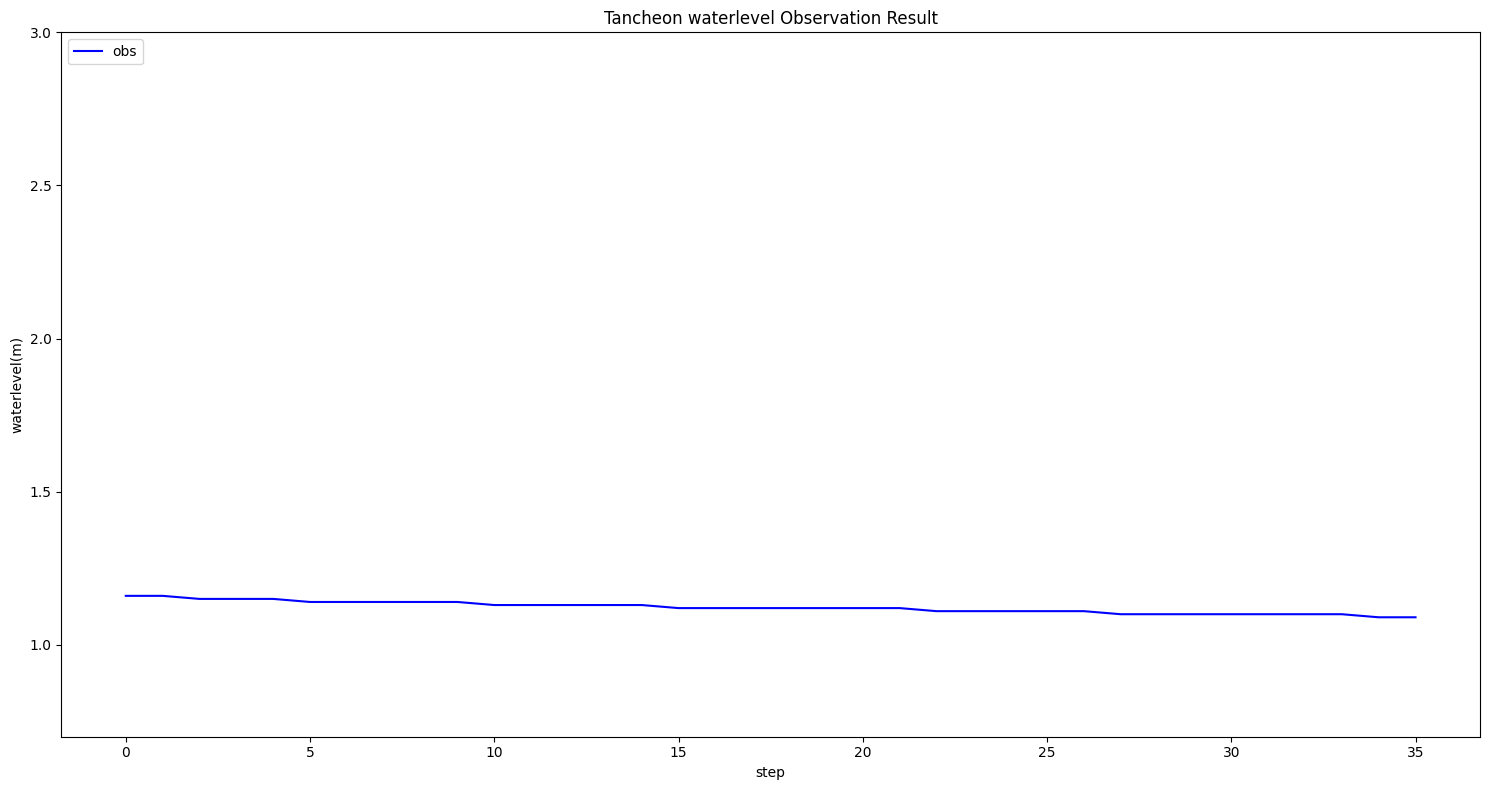

In [9]:
# drawRealGraph(data ,TARGET_COL, 'waterflow')
drawRealGraph(data ,WL_COL, 'waterlevel')

In [10]:
# drawCorrectionGraph(output, y_pred, 'waterflow')

In [11]:
# 메트릭 계산
# r2 = r2_score(output, y_pred)
# mse = mean_squared_error(output, y_pred)
# mae = mean_absolute_error(output, y_pred)
# rmse = np.sqrt(mse)

In [12]:
y_pred2 = np.array([QHCurve(f) for f in y_pred])       # 관측 유량(Q_obs) → 환산 수위(H_obs_from_Q)
# output2 = np.array([QHCurve(f) for f in output])     # 기존 코드 : 예측 유량(Q_pred) → 예측 수위(H_pred)
output2 = data[WL_COL].to_numpy()[-36:]                # 수정 코드 : 진짜 관측 수위

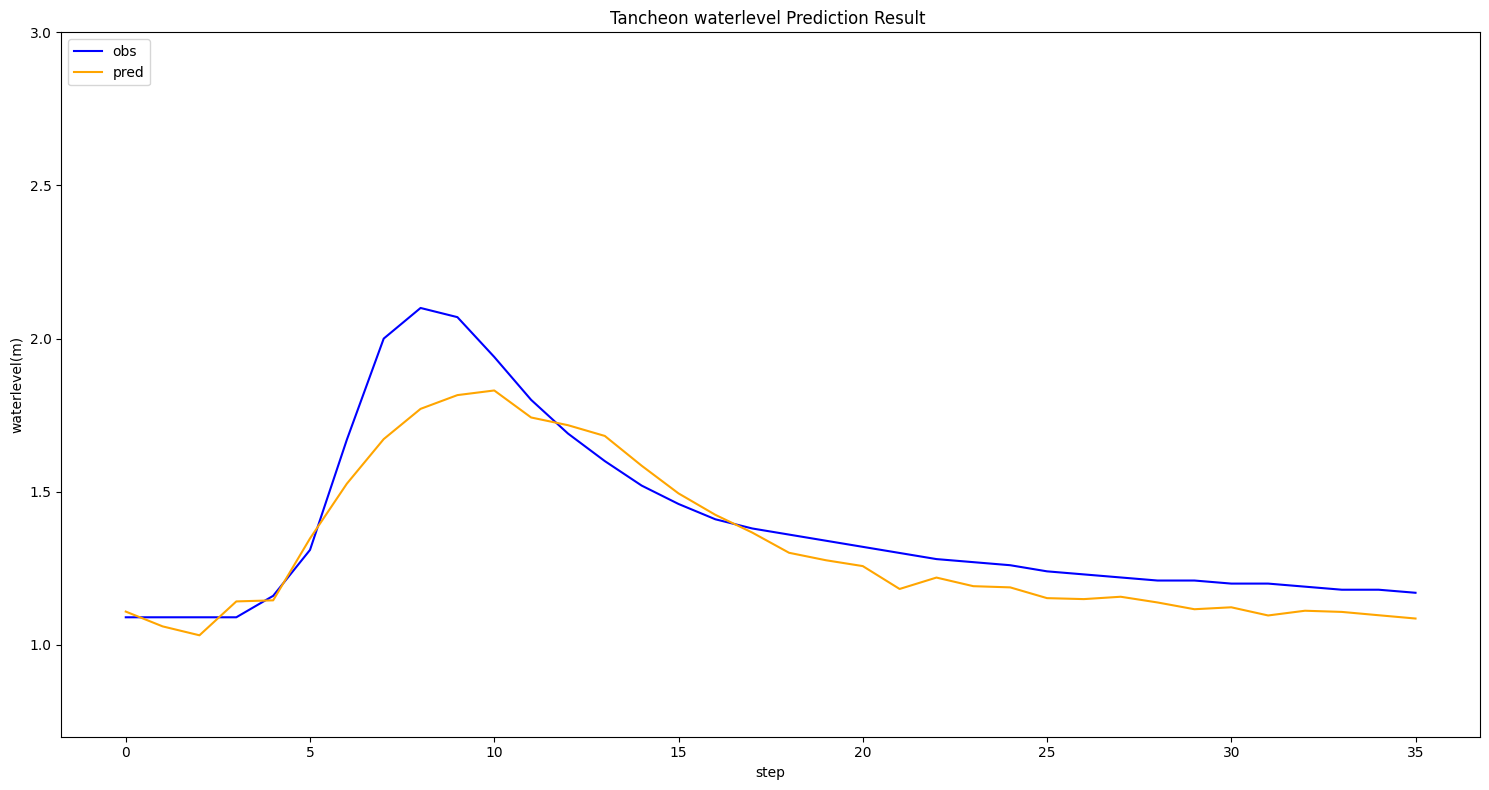

In [13]:
drawCorrectionGraph(output2, y_pred2, 'waterlevel')

In [14]:
# 메트릭 계산
r2 = r2_score(output2, y_pred2)
mse = mean_squared_error(output2, y_pred2)
mae = mean_absolute_error(output2, y_pred2)
rmse = np.sqrt(mse)

In [15]:
# drawRainGraph(data, target_key)

In [16]:
# 메트릭 계산 결과 출력
print(f'''
r2 : {r2}
mse : {mse}
mae : {mae}
rmse : {rmse}
''')


r2 : 0.8441383912296039
mse : 0.012609528861209982
mae : 0.08559906786194965
rmse : 0.11229215850276449



In [ ]:
# makeResultChart(data, y_pred, r2, mse, mae, rmse)
makeResultChart(data, y_pred2, r2, mse, mae, rmse)

 신규 파일 생성 :  ./testdata/result/240723_유량수위곡선식.xlsx
✅ 저장 완료: ./testdata/result/240723_유량수위곡선식.xlsx
